<a href="https://www.kaggle.com/code/subhranilwayne/working-with-images?scriptVersionId=356986620" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/subhranilwayne/my-image-dataset/1000121789.jpg.jpeg


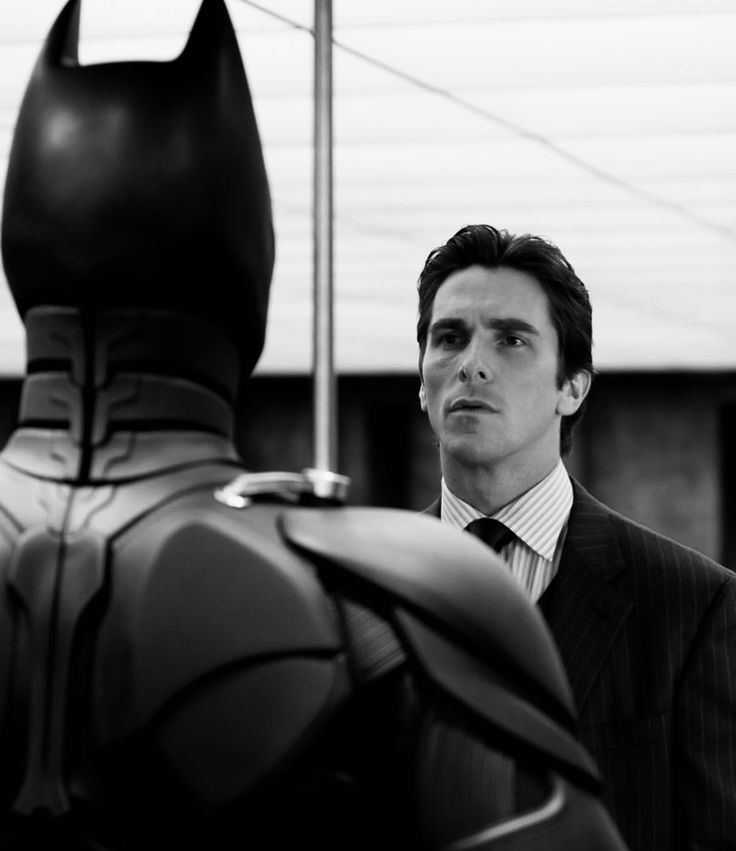

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

file_path = "/kaggle/input/datasets/subhranilwayne/my-image-dataset/1000121789.jpg.jpeg"
img = Image.open(file_path)
img

In [3]:
img_mtx = np.array(img)
img_mtx

array([[[245, 245, 245],
        [245, 245, 245],
        [245, 245, 245],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[245, 245, 245],
        [245, 245, 245],
        [245, 245, 245],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       [[245, 245, 245],
        [245, 245, 245],
        [245, 245, 245],
        ...,
        [242, 242, 242],
        [242, 242, 242],
        [242, 242, 242]],

       ...,

       [[  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [  2,   2,   2],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [  2,   2,   2],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [  2,   2,   2],
        [  1,   1,   1],
        [  1,   1,   1]]

In [4]:
# 4. Check the structural data dimensions
print("Matrix Shape (Height, Width, Channels):", img_mtx.shape)
print("Data Type of Pixels:", img_mtx.dtype)
print("Maximum Pixel Value:", img_mtx.max())
print("Minimum Pixel Value:", img_mtx.min())

Matrix Shape (Height, Width, Channels): (851, 736, 3)
Data Type of Pixels: uint8
Maximum Pixel Value: 255
Minimum Pixel Value: 0


### we want to collapse those 3 color planes into a single brightness plane using the weighted ITU-R 601 standard formula:
### Grayscale=(0.299 * R)+(0.587 * G)+(0.114 * B)

In [5]:
R = img_mtx[:,:,0]
G = img_mtx[:,:,1]
B = img_mtx[:,:,2]

# APPLY THE MATHEMATICAL FORMULA
gray_matrix = (0.299 * R) + (0.587 * G) + (0.114 * B)

# Convert the resulting floats back to 8-bit integers so it stays a valid image format
gray_matrix = gray_matrix.astype(np.uint8)

print("New Grayscale Matrix Shape:", gray_matrix.shape) # It will now be 2D: (Height, Width)

New Grayscale Matrix Shape: (851, 736)


# Visualising the matrix comparison,

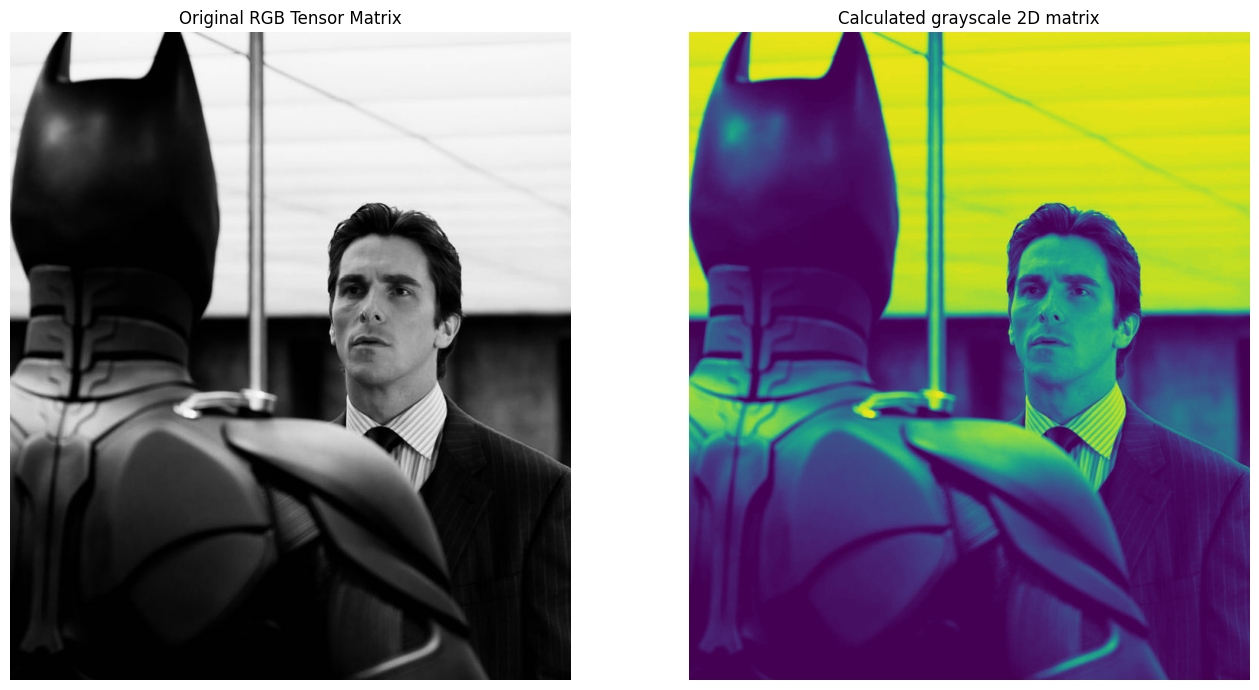

In [6]:
fig, axes = plt.subplots(1,2,figsize=(14,7))

# Plot the original RGB tensor
axes[0].imshow(img_mtx)
axes[0].set_title("Original RGB Tensor Matrix")
axes[0].axis("off")

# plot calculated 2d grayscale matrix
axes[1].imshow(gray_matrix)
axes[1].set_title("Calculated grayscale 2D matrix")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
print("Type:", type(img_mtx))
print("Shape:", getattr(img_mtx, "shape", "No shape attribute"))

Type: <class 'numpy.ndarray'>
Shape: (851, 736, 3)


# Pixel level manipulation

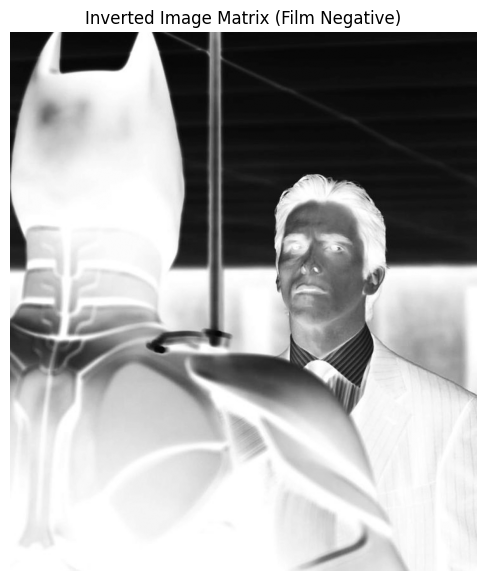

In [8]:
# Invert the pixel intensity values completely using board array subtraction
inverted_mtx = 255 - gray_matrix

# Render our manual tranformation
plt.figure(figsize=(7,7))
plt.imshow(inverted_mtx, cmap = "gray")
plt.title("Inverted Image Matrix (Film Negative)")
plt.axis("Off")
plt.show()

### Sampling and Quantisation are the two foundational pillars that turn a continuous real-world scene into a digital grid of numbers.


## 1. Spatial Down-Sampling (Resolution Reduction)

Sampling determines the spatial resolution of your image (the number of pixels). If you down-sample, you throw away rows and columns.
- The Experiment: We will skip pixels using NumPy slicing intervals [: : step]. For instance, [: : 2] takes every second pixel, reducing a 1080p image down to a smaller grid.

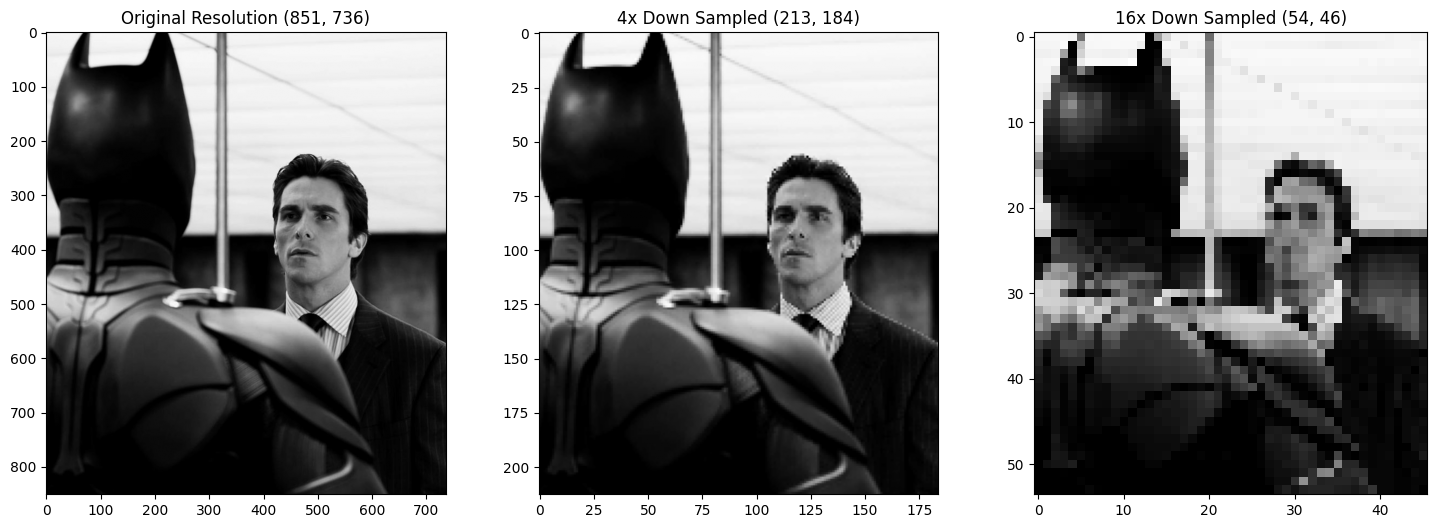

In [9]:
# Down-sampling by taking every 4th pixel
sampled_4x  = gray_matrix[::4,::4]

# Down-sampling aggressively by taking every 16th pixel
sampled_16x = gray_matrix[::16,::16]

# Plot the result
fig,axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(gray_matrix,cmap = "gray")
axes[0].set_title(f"Original Resolution {gray_matrix.shape}")

axes[1].imshow(sampled_4x,cmap = "gray")
axes[1].set_title(f"4x Down Sampled {sampled_4x.shape}")

axes[2].imshow(sampled_16x,cmap = "gray")
axes[2].set_title(f"16x Down Sampled {sampled_16x.shape}")

plt.show()

# 2. Bit-Depth Quantisation (Intensity Reduction)

**Quantisation** determines how many distinct shades of gray a single pixel can represent (the bit-depth). A normal standard image is 8-bit, giving you 2⁸ = 256 intensity levels (0 to 255).
- **The Experiment**: We will artificially compress the range of numbers to simulate lower bit depths like 4-bit (2⁴ = 16 levels), 2-bit (2² = 4 levels), or even 1-bit binary (2¹ = 2 levels: pure black or pure white).

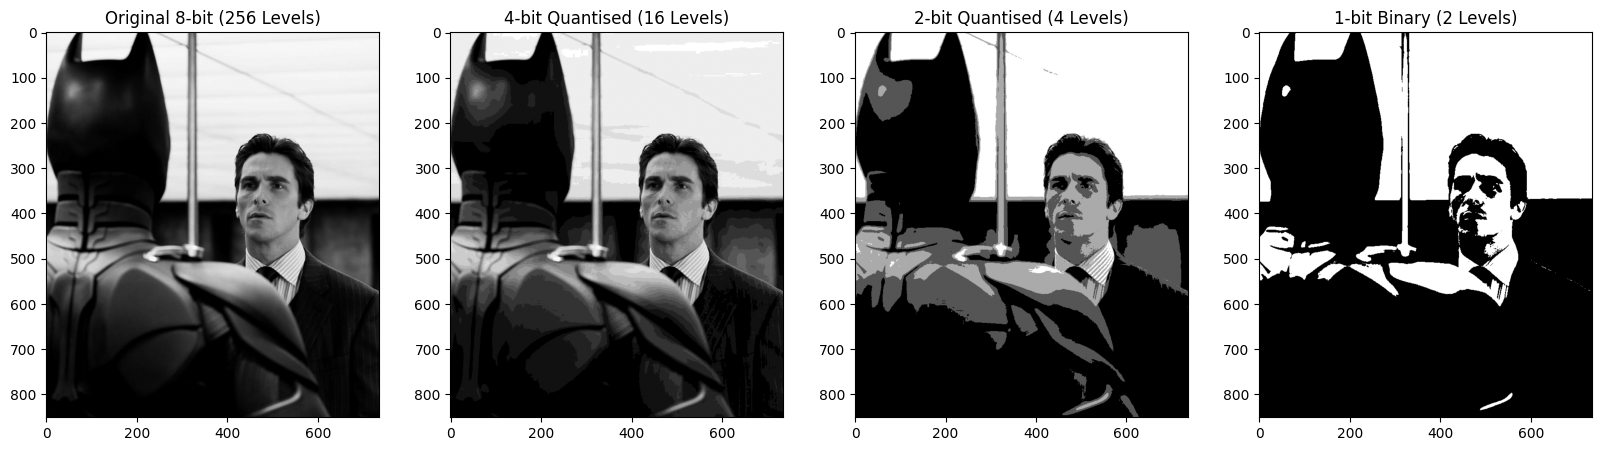

In [10]:
def quantize_image(img, bits):
    # Calculate total unique levels for the target bit depth
    levels = 2**bits
    
    # Scale 0-255 down to 0-(levels-1), round it to integers, then scale back up
    scale_factor = 255 / (levels - 1)
    quantized = np.round(img / scale_factor) * scale_factor
    return quantized.astype(np.uint8)

# Generate different bit depths
quant_4bit = quantize_image(gray_matrix, bits=4) # 16 shades of gray
quant_2bit = quantize_image(gray_matrix, bits=2) # 4 shades of gray
quant_1bit = quantize_image(gray_matrix, bits=1) # 2 shades (Thresholded/Binary)

# Plot the intensity reduction
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(gray_matrix, cmap='gray')
axes[0].set_title("Original 8-bit (256 Levels)")

axes[1].imshow(quant_4bit, cmap='gray')
axes[1].set_title("4-bit Quantised (16 Levels)")

axes[2].imshow(quant_2bit, cmap='gray')
axes[2].set_title("2-bit Quantised (4 Levels)")

axes[3].imshow(quant_1bit, cmap='gray')
axes[3].set_title("1-bit Binary (2 Levels)")
plt.show()

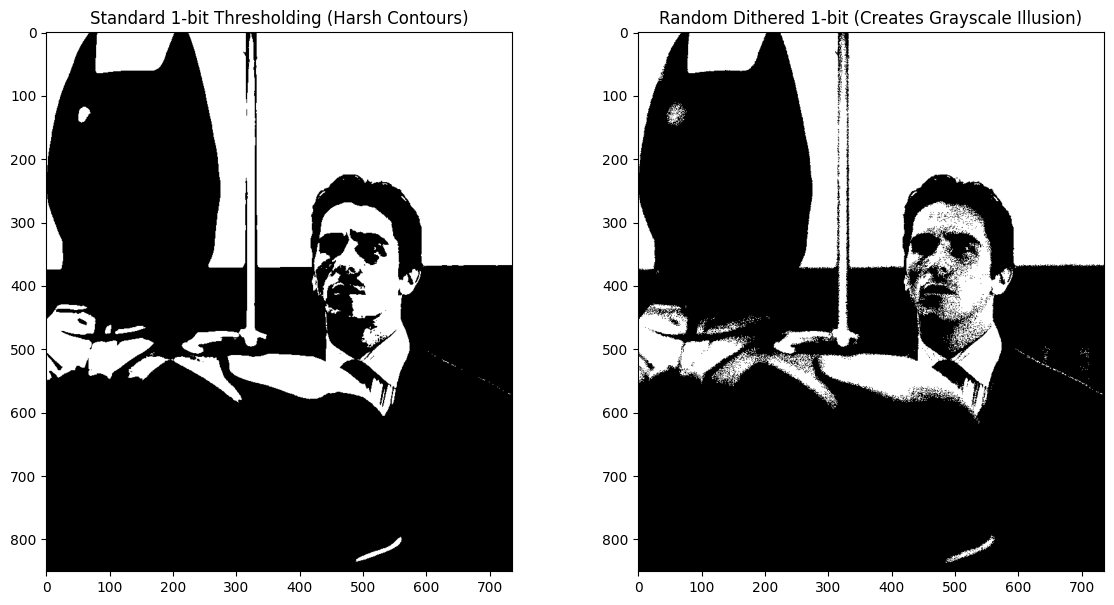

In [11]:
# 1. Standard clean 1-bit thresholding
binary_clean = (gray_matrix > 127).astype(np.uint8) * 255

# 2. Dithered 1-bit thresholding: Add uniform random noise to the image first
noise = np.random.uniform(-30, 30, size=gray_matrix.shape)
noisy_gray = gray_matrix.astype(float) + noise

# Threshold the noisy image
binary_dithered = (noisy_gray > 127).astype(np.uint8) * 255

# Compare them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(binary_clean, cmap='gray')
axes[0].set_title("Standard 1-bit Thresholding (Harsh Contours)")

axes[1].imshow(binary_dithered, cmap='gray')
axes[1].set_title("Random Dithered 1-bit (Creates Grayscale Illusion)")
plt.show()